## MAT-1 check from burst continuous 


In [1]:
# ------------------------------------------------------------
# Imports

import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob
import gsw
import datetime
import pandas as pd

# End imports
# ------------------------------------------------------------


In [2]:
# ------------------------------------------------------------
# Definitions

def compute_orientation(df):
    Ax = df["Ax (g)"].to_numpy()
    Ay = df["Ay (g)"].to_numpy()
    Az = df["Az (g)"].to_numpy()
    Mx = df["Mx (mG)"].to_numpy()
    My = df["My (mG)"].to_numpy()
    Mz = df["Mz (mG)"].to_numpy()

    # Pitch and Roll from accelerometer
    pitch = np.arctan2(-Ax, np.sqrt(Ay**2 + Az**2))
    roll = np.arctan2(Ay, Az)

    # Yaw estimate from magnetometer and pitch/roll
    mag_x = Mx * np.cos(pitch) + Mz * np.sin(pitch)
    mag_y = Mx * np.sin(roll) * np.sin(pitch) + My * np.cos(roll) - Mz * np.sin(roll) * np.cos(pitch)
    yaw = np.arctan2(-mag_y, mag_x)

    # Convert radians to degrees
    pitch_deg = np.degrees(pitch)
    roll_deg = np.degrees(roll)
    yaw_deg = np.degrees(yaw)

    df["Pitch"] = pitch_deg
    df["Roll"] = roll_deg + 180
    df["Yaw"] = yaw_deg
    # Optional: wrap angles to 0–360
    df["Pitch"] = (df["Pitch"] + 360) % 360
    df["Roll"] = (df["Roll"] + 360) % 360
    df["Yaw"] = (df["Yaw"] + 360) % 360

    return df

# OPTIONAL - remove outliers

def remove_outliers(df, columns, std_threshold=5):
    df_clean = df.copy()
    outlier_info = {}
    
    for col in columns:
        if col in df_clean.columns:
            mean = df_clean[col].mean()
            std = df_clean[col].std()
            
            lower_bound = mean - std_threshold * std
            upper_bound = mean + std_threshold * std
            
            outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
            n_outliers = outliers_mask.sum()
            
            if n_outliers > 0:
                print(f"Column '{col}': Removing {n_outliers} outliers "
                      f"(< {lower_bound:.3f} or > {upper_bound:.3f})")
                
                outlier_info[col] = {
                    'n_outliers': n_outliers,
                    'lower_bound': lower_bound,
                    'upper_bound': upper_bound,
                    'outlier_values': df_clean.loc[outliers_mask, col].values
                }
                
                df_clean.loc[outliers_mask, col] = np.nan
            else:
                print(f"Column '{col}': No outliers found")
    
    df_clean = df_clean.dropna(subset=columns, how='all')
    
    print(f"Original rows: {len(df)}, After outlier removal: {len(df_clean)}")
    
    return df_clean, outlier_info

# End Definitions
# ------------------------------------------------------------

In [3]:
# ------------------------------------------------------------
# Start Main
# ------------------------------------------------------------

# Definitions

# naming params 
channels = 'acc'
# sd = r_start_time.strftime("%Y%m%dT%H%M%SZ")
processing_ver = 2
inst_type = 'MAT1'

# goes to the targeted directory where the data file is expected. 
fgen = '/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/data_in'

# folder = fgen+'/rec_202408/BASS3A_PTSUVW_202408/RBRQ3_209968'
list_folders=['rec_202603/BASJAS_PTSUVW_202603/MAT1_2112075']

# Loop on folders to process
for f in list_folders:
    sn = f.split("_")[4]
    sni = int(f.split("_")[4])
    site = f.split("_")[1].split("/")[1].split("BAS")[1]
    print(f"{f} : sn = {sn} , site = {site}")
    folder=fgen+'/'+f
    # os.chdir(folder)
    # os.getcwd()
    filist = sorted(glob.glob(f"{folder}/*_AccelMag.csv"))
    file_in=filist[0]  # incase there's multiple _data file it only looks at the first one. if there is to be multiple file for a deployment, one would have a to look into looping throught the list or something.
    pf_code = f"BAS{site}"
    print('processing ',file_in)
    # read that file into a pandas dataframe
    df = pd.read_csv(file_in , parse_dates=["ISO 8601 Time"])
    ## Define start and end times and select the "in water" part of the dataset (still a pandas dataframe)

# Rename the timestamp column for convenience
df.rename(columns={"ISO 8601 Time": "Time"}, inplace=True)

print(df.head())


rec_202603/BASJAS_PTSUVW_202603/MAT1_2112075 : sn = 2112075 , site = JAS
processing  /datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/data_in/rec_202603/BASJAS_PTSUVW_202603/MAT1_2112075/2112075_JAS-PTSUVW_AccelMag.csv
                     Time  Ax (g)  Ay (g)  Az (g)  Mx (mG)  My (mG)  Mz (mG)
0 2025-02-01 00:00:00.000  0.0043  0.0021 -1.0068   -80.19  -110.00   856.18
1 2025-02-01 00:00:00.250  0.0033  0.0018 -1.0063   -80.17  -113.39   852.86
2 2025-02-01 00:00:00.500  0.0040  0.0023 -1.0063   -81.72  -113.42   854.41
3 2025-02-01 00:00:00.750  0.0028  0.0016 -1.0068   -80.20  -113.43   854.41
4 2025-02-01 00:00:01.000  0.0045  0.0021 -1.0073   -80.18  -111.54   854.36


In [4]:
# compute the orientations
df = compute_orientation(df)
print(f"Data shape after orientation calculation: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Data shape after orientation calculation: (131910584, 10)
Columns: ['Time', 'Ax (g)', 'Ay (g)', 'Az (g)', 'Mx (mG)', 'My (mG)', 'Mz (mG)', 'Pitch', 'Roll', 'Yaw']


,Time,Ax (g),Ay (g),Az (g),Mx (mG),My (mG),Mz (mG),Pitch,Roll,Yaw
0,2025-02-01 00:00:00.000,0.0043,0.0021,-1.0068,-80.19,-110.00,856.18,359.755294,359.880492,232.231073
1,2025-02-01 00:00:00.250,0.0033,0.0018,-1.0063,-80.17,-113.39,852.86,359.812109,359.897513,233.436903
2,2025-02-01 00:00:00.500,0.0040,0.0023,-1.0063,-81.72,-113.42,854.41,359.772253,359.869045,232.635009
3,2025-02-01 00:00:00.750,0.0028,0.0016,-1.0068,-80.20,-113.43,854.41,359.840656,359.908946,233.616905
4,2025-02-01 00:00:01.000,0.0045,0.0021,-1.0073,-80.18,-111.54,854.36,359.744040,359.880551,232.574137


In [5]:
# Remove outliers from accelerometer data
print("=== Removing outliers from accelerometer data ===")
accel_columns = ['Ax (g)', 'Ay (g)', 'Az (g)', 'Mx (mG)', 'My (mG)', 'Mz (mG)']
df_accel_clean, accel_outlier_info = remove_outliers(df, accel_columns, std_threshold=5)

# Recompute orientations after outlier removal
print("\n=== Recomputing orientations after outlier removal ===")
df_accel_clean = compute_orientation(df_accel_clean)

print(f"\nAccelerometer data shape after outlier removal: {df_accel_clean.shape}")
print("First few rows after cleaning:")
print(df_accel_clean[['Time'] + accel_columns + ['Pitch', 'Roll', 'Yaw']].head())

=== Removing outliers from accelerometer data ===
Column 'Ax (g)': Removing 90716 outliers (< -0.023 or > 0.035)
Column 'Ay (g)': Removing 121675 outliers (< -0.021 or > 0.043)
Column 'Az (g)': Removing 187281 outliers (< -1.021 or > -0.988)
Column 'Mx (mG)': Removing 1925387 outliers (< 27.578 or > 373.402)
Column 'My (mG)': Removing 1968362 outliers (< -2.487 or > 380.901)
Column 'Mz (mG)': Removing 423358 outliers (< 681.651 or > 877.330)
Original rows: 131910584, After outlier removal: 131905664

=== Recomputing orientations after outlier removal ===

Accelerometer data shape after outlier removal: (131905664, 10)
First few rows after cleaning:
                     Time  Ax (g)  Ay (g)  Az (g)  Mx (mG)  My (mG)  Mz (mG)  \
0 2025-02-01 00:00:00.000  0.0043  0.0021 -1.0068      NaN      NaN   856.18   
1 2025-02-01 00:00:00.250  0.0033  0.0018 -1.0063      NaN      NaN   852.86   
2 2025-02-01 00:00:00.500  0.0040  0.0023 -1.0063      NaN      NaN   854.41   
3 2025-02-01 00:00:00.7

Time filter applied: 2025-02-07 00:00:00 to 2025-03-04 02:15:00
Filtered accelerometer data: 8,671,714 rows


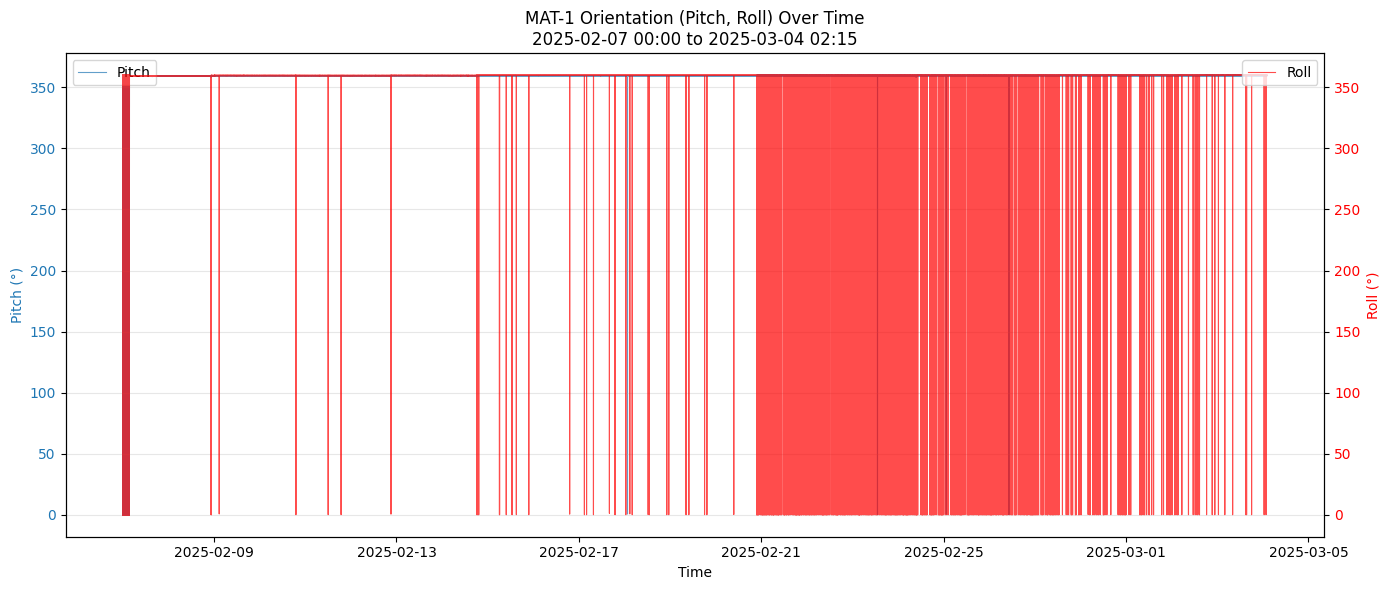

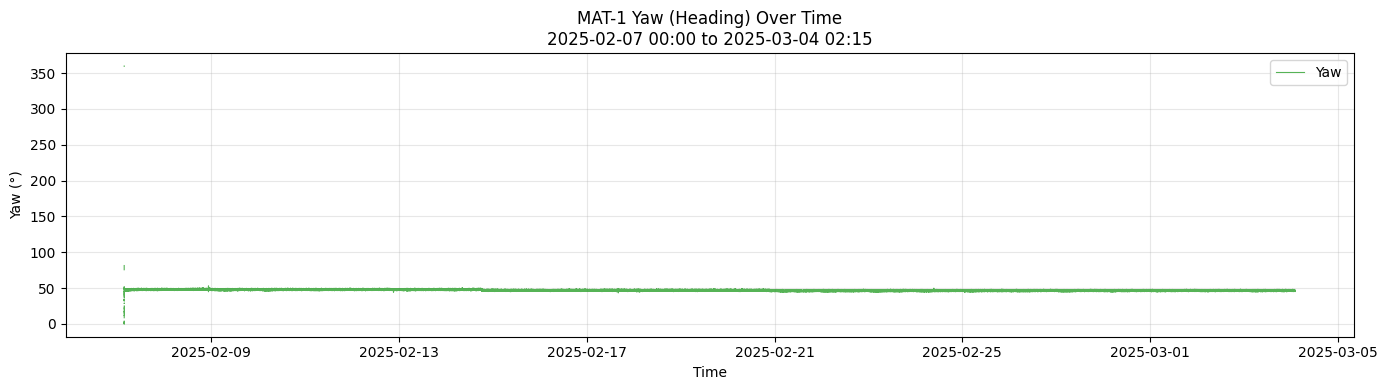

✓ Plots using your specified time range: 8,671,714 data points
Note: Use matplotlib's zoom and pan tools in the toolbar for interactivity


In [7]:
# Set time filter first (needs to be defined before plotting)
time_start = pd.to_datetime("2025-02-07T00:00:00")  # Your specified start time
time_end = pd.to_datetime("2025-03-04T02:15:00")    # Your specified end time

# Apply time filtering to accelerometer data
df_accel_filtered = df_accel_clean[(df_accel_clean["Time"] >= time_start) & (df_accel_clean["Time"] <= time_end)]

print(f"Time filter applied: {time_start} to {time_end}")
print(f"Filtered accelerometer data: {len(df_accel_filtered):,} rows")

# FIXED: Accelerometer/Magnetometer Pitch, Roll, Yaw plots
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Y-axis for pitch 
ax1.plot(df_accel_filtered["Time"], df_accel_filtered["Pitch"], label="Pitch", color="tab:blue", alpha=0.7, linewidth=0.8)
ax1.set_xlabel("Time")
ax1.set_ylabel("Pitch (°)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.legend(loc="upper left")

# Right axis: Roll
ax2 = ax1.twinx()
ax2.plot(df_accel_filtered["Time"], df_accel_filtered["Roll"], 'r-', label='Roll', alpha=0.7, linewidth=0.8)
ax2.set_ylabel('Roll (°)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc="upper right")

plt.title(f"MAT-1 Orientation (Pitch, Roll) Over Time\n{time_start.strftime('%Y-%m-%d %H:%M')} to {time_end.strftime('%Y-%m-%d %H:%M')}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot yaw separately for clarity
plt.figure(figsize=(14, 4))
plt.plot(df_accel_filtered["Time"], df_accel_filtered["Yaw"], label="Yaw", color="tab:green", alpha=0.8, linewidth=0.8)
plt.title(f"MAT-1 Yaw (Heading) Over Time\n{time_start.strftime('%Y-%m-%d %H:%M')} to {time_end.strftime('%Y-%m-%d %H:%M')}")
plt.xlabel("Time")
plt.ylabel("Yaw (°)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Plots using your specified time range: {len(df_accel_filtered):,} data points")
print("Note: Use matplotlib's zoom and pan tools in the toolbar for interactivity")

/tmp/ipykernel_4623/15633009.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/datasets/work/oa-srsalt/work/envs/ash/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


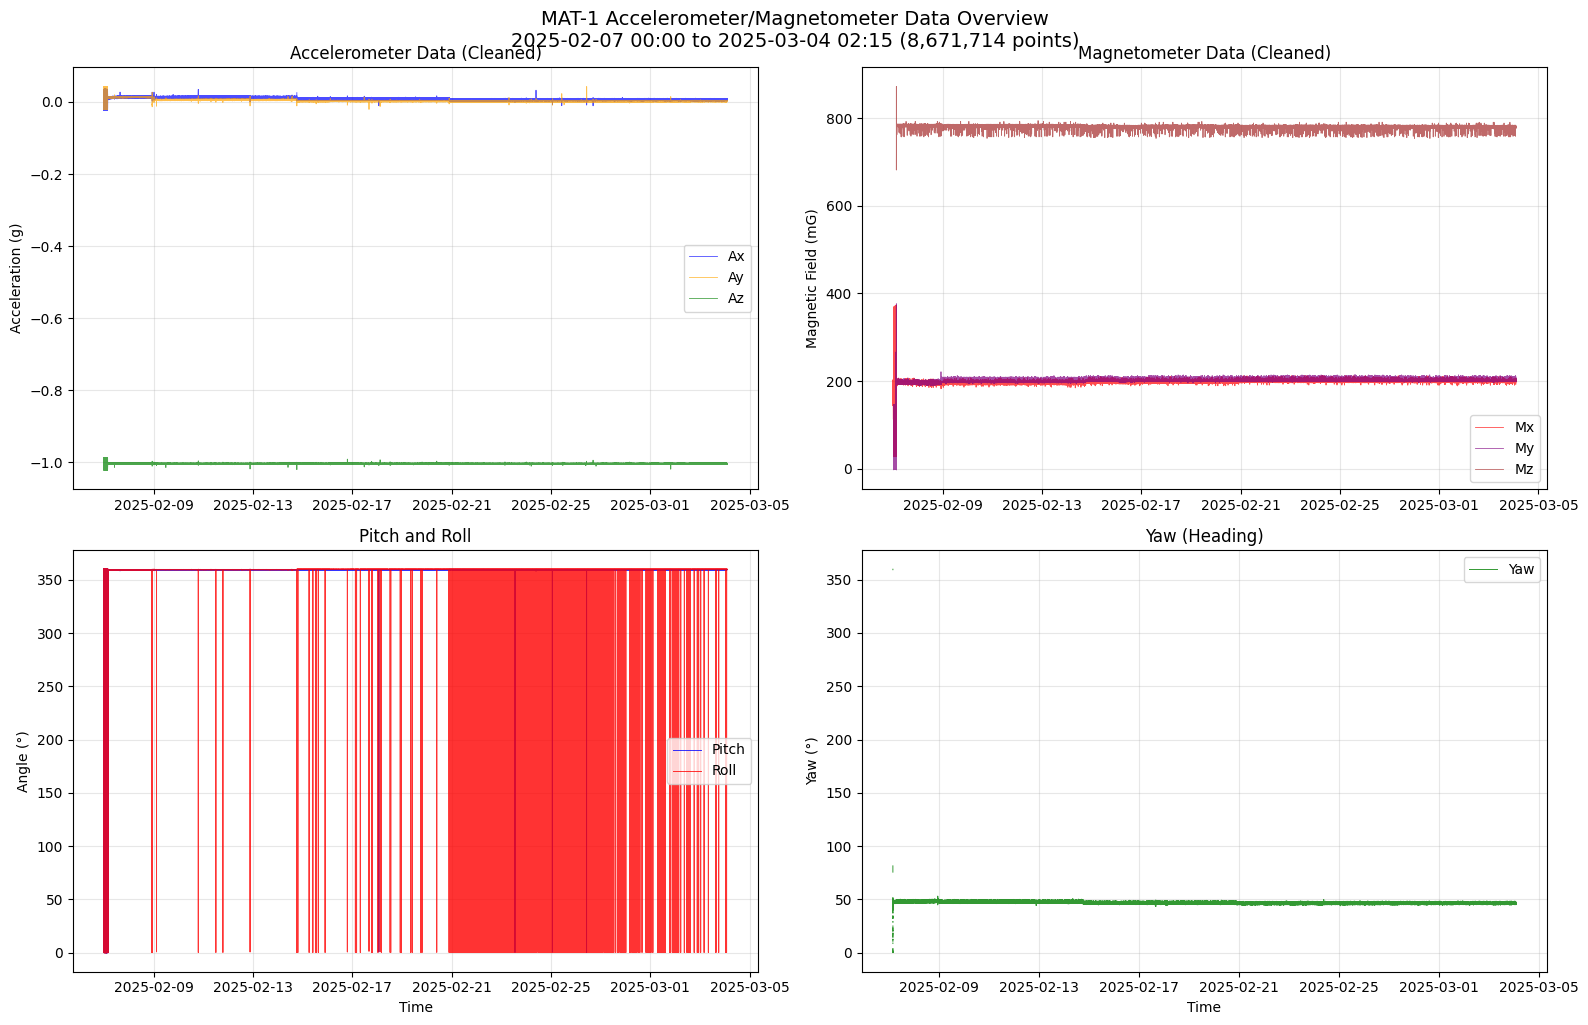

✓ Raw sensor overview using your specified time range: 8,671,714 data points


In [8]:
# Use the consistently filtered dataset
df_display = df_accel_filtered  # Uses your specified time range

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Acceleration components
axes[0, 0].plot(df_display["Time"], df_display["Ax (g)"], label="Ax", alpha=0.7, color='blue', linewidth=0.6)
axes[0, 0].plot(df_display["Time"], df_display["Ay (g)"], label="Ay", alpha=0.7, color='orange', linewidth=0.6) 
axes[0, 0].plot(df_display["Time"], df_display["Az (g)"], label="Az", alpha=0.7, color='green', linewidth=0.6)
axes[0, 0].set_title("Accelerometer Data (Cleaned)")
axes[0, 0].set_ylabel("Acceleration (g)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Magnetometer components
axes[0, 1].plot(df_display["Time"], df_display["Mx (mG)"], label="Mx", alpha=0.7, color='red', linewidth=0.6)
axes[0, 1].plot(df_display["Time"], df_display["My (mG)"], label="My", alpha=0.7, color='purple', linewidth=0.6)
axes[0, 1].plot(df_display["Time"], df_display["Mz (mG)"], label="Mz", alpha=0.7, color='brown', linewidth=0.6)
axes[0, 1].set_title("Magnetometer Data (Cleaned)")
axes[0, 1].set_ylabel("Magnetic Field (mG)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Pitch and Roll
axes[1, 0].plot(df_display["Time"], df_display["Pitch"], label="Pitch", alpha=0.8, color='blue', linewidth=0.7)
axes[1, 0].plot(df_display["Time"], df_display["Roll"], label="Roll", alpha=0.8, color='red', linewidth=0.7)
axes[1, 0].set_title("Pitch and Roll")
axes[1, 0].set_ylabel("Angle (°)")
axes[1, 0].set_xlabel("Time")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Yaw (Heading)
axes[1, 1].plot(df_display["Time"], df_display["Yaw"], label="Yaw", alpha=0.8, color='green', linewidth=0.7)
axes[1, 1].set_title("Yaw (Heading)")
axes[1, 1].set_ylabel("Yaw (°)")
axes[1, 1].set_xlabel("Time")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'MAT-1 Accelerometer/Magnetometer Data Overview\n{time_start.strftime("%Y-%m-%d %H:%M")} to {time_end.strftime("%Y-%m-%d %H:%M")} ({len(df_display):,} points)', 
             y=1.02, fontsize=14)
plt.show()

print(f"✓ Raw sensor overview using your specified time range: {len(df_display):,} data points")

In [ ]:
# # ------------------------------------------------------------
# # Currents
# # ------------------------------------------------------------

# # Definitions

# # naming params 
# channels = 'cur'
# # sd = r_start_time.strftime("%Y%m%dT%H%M%SZ")
# processing_ver = 2
# inst_type = 'MAT1'

# # goes to the targeted directory where the data file is expected. 
# fgen = '/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/data_in'

# # folder = fgen+'/rec_202408/BASS3A_PTSUVW_202408/RBRQ3_209968'
# list_folders=['rec_202603/BASJAS_PTSUVW_202603/MAT1_2112075']

# # Loop on folders to process
# for f in list_folders:
#     sn = f.split("_")[4]
#     sni = int(f.split("_")[4])
#     site = f.split("_")[1].split("/")[1].split("BAS")[1]
#     print(f"{f} : sn = {sn} , site = {site}")
#     folder=fgen+'/'+f
#     # os.chdir(folder)
#     # os.getcwd()
#     filist = sorted(glob.glob(f"{folder}/MAT-1_2112074_2025_09_01_2112074_JAS-PTSUV_(0)_Current.csv"))
#     file_in=filist[0]  # incase there's multiple _data file it only looks at the first one. if there is to be multiple file for a deployment, one would have a to look into looping throught the list or something.
#     pf_code = f"BAS{site}"
#     print('processing ',file_in)
    
#     # Try to read the CSV with error handling for malformed lines
#     try:
#         # First, try the normal approach
#         df_currents = pd.read_csv(file_in, parse_dates=["ISO 8601 Time"])  # Changed to df_currents
#         print("Successfully read CSV file")
#     except pd.errors.ParserError as e:
#         # print(f"Parser error encountered: {e}")
#         # print("Trying alternative approaches...")
        
#         # Option 1: Skip bad lines
#         try:
#             df_currents = pd.read_csv(file_in, parse_dates=["ISO 8601 Time"], on_bad_lines='skip')  # Changed to df_currents
#             # print("Successfully read CSV by skipping bad lines")
#         except Exception as e2:
#             print(f"Skip bad lines approach failed: {e2}")
            
#             # # Option 2: Use python engine which is more forgiving
#             # try:
#             #     df = pd.read_csv(file_in, parse_dates=["ISO 8601 Time"], engine='python', on_bad_lines='skip')
#             #     print("Successfully read CSV using Python engine")
#             # except Exception as e3:
#             #     print(f"Python engine approach failed: {e3}")
                
#             #     # Option 3: Read without date parsing first, then convert
#             #     try:
#             #         df = pd.read_csv(file_in, engine='python', on_bad_lines='skip')
#             #         df["ISO 8601 Time"] = pd.to_datetime(df["ISO 8601 Time"])
#             #         print("Successfully read CSV and converted dates separately")
#             #     except Exception as e4:
#             #         print(f"All approaches failed: {e4}")
#             #         raise e4

# # Rename the timestamp column for convenience
# df_currents.rename(columns={"ISO 8601 Time": "Time"}, inplace=True)  # Changed to df_currents

# print(df_currents.head())

In [ ]:
# # Remove outliers from current data
# print("=== Removing outliers from current data ===")
# current_columns = ['Speed (cm/s)', 'Heading (degrees)', 'Velocity-N (cm/s)', 'Velocity-E (cm/s)']
# df_currents_clean, current_outlier_info = remove_outliers(df_currents, current_columns, std_threshold=5)

# print(f"\nCurrent data shape after outlier removal: {df_currents_clean.shape}")
# print("First few rows after cleaning:")
# print(df_currents_clean[['Time'] + current_columns].head())

In [ ]:
# Check actual data time ranges
print("=== Data Time Ranges ===")
print(f"Accelerometer data:")
print(f"  Start: {df_accel_clean['Time'].min()}")
print(f"  End: {df_accel_clean['Time'].max()}")
# print(f"Current data:")
# print(f"  Start: {df_currents_clean['Time'].min()}")
# print(f"  End: {df_currents_clean['Time'].max()}")
# print(f"\nCurrent time filter settings:")
# print(f"  time_start: {time_start}")
# print(f"  time_end: {time_end}")

# Check if we have data in the filtered range
accel_in_range = df_accel_clean[(df_accel_clean["Time"] >= time_start) & (df_accel_clean["Time"] <= time_end)]
current_in_range = df_currents_clean[(df_currents_clean["Time"] >= time_start) & (df_currents_clean["Time"] <= time_end)]
print(f"\nFiltered data counts:")
print(f"  Accelerometer: {len(accel_in_range):,} rows")
print(f"  Current: {len(current_in_range):,} rows")

In [ ]:
# Check if plotly is available and install if needed
try:
    import plotly.graph_objects as go
    import plotly.subplots as sp
    from plotly.subplots import make_subplots
    print("✓ Plotly is available - can make interactive plots!")
    PLOTLY_AVAILABLE = True
except ImportError:
    print("! Plotly not available - will use matplotlib")
    PLOTLY_AVAILABLE = False
    
# CORRECTED: Use your specified time filter settings for all plots
print("\n=== Setting consistent time filter for all plots ===")
time_start = pd.to_datetime("2024-07-31T05:20:00")  # Your specified start time
time_end = pd.to_datetime("2025-08-23T04:10:00")    # Your specified end time
print(f"time_start: {time_start}")
print(f"time_end: {time_end}")

# Apply the consistent time filtering to both datasets
df_accel_filtered = df_accel_clean[(df_accel_clean["Time"] >= time_start) & (df_accel_clean["Time"] <= time_end)]
df_currents_filtered = df_currents_clean[(df_currents_clean["Time"] >= time_start) & (df_currents_clean["Time"] <= time_end)]
print(f"Accelerometer filtered data: {len(df_accel_filtered):,} rows")
print(f"Current filtered data: {len(df_currents_filtered):,} rows")

In [ ]:
# # FIXED: Current data plots with your specified time range
# # All plots now use consistent time filtering: 2024-07-31T05:20:00 to 2025-08-23T04:10:00

# # Process and plot current data (cleaned)
# # Resample to 10-minute intervals and convert cm/s to m/s
# df_10min = df_currents_clean.set_index("Time").resample("10T").mean()
# df_10min["Speed (m/s)"] = df_10min["Speed (cm/s)"] / 100
# df_10min["Velocity-N (m/s)"] = df_10min["Velocity-N (cm/s)"] / 100
# df_10min["Velocity-E (m/s)"] = df_10min["Velocity-E (cm/s)"] / 100

# df_10min = df_10min.reset_index()
# print("10-minute averaged current data:")
# print(df_10min.head())

# # Filter by YOUR specified time period (consistent across all plots)
# df_10min_filtered = df_10min[(df_10min["Time"] >= time_start) & (df_10min["Time"] <= time_end)]
# df_currents_display = df_currents_filtered  # Already filtered with your time range

# print(f"Filtered current data: {len(df_10min_filtered):,} 10-min points, {len(df_currents_display):,} raw points")

# # Create comprehensive current plots
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# # Current speed
# axes[0, 0].plot(df_10min_filtered["Time"], df_10min_filtered["Speed (m/s)"], 
#                label="Speed", alpha=0.8, color='blue', linewidth=0.8)
# axes[0, 0].set_title("Current Speed (10-min average)")
# axes[0, 0].set_ylabel("Speed (m/s)")
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # Current heading (use consistently filtered data)
# axes[0, 1].scatter(df_currents_display["Time"], df_currents_display["Heading (degrees)"], 
#                alpha=0.4, color='orange', s=0.1)
# axes[0, 1].set_title("Current Heading")
# axes[0, 1].set_ylabel("Heading (degrees)")
# axes[0, 1].grid(True, alpha=0.3)

# # Velocity components
# axes[1, 0].plot(df_10min_filtered["Time"], df_10min_filtered["Velocity-N (m/s)"], 
#                label="North", alpha=0.8, color='green', linewidth=0.8)
# axes[1, 0].plot(df_10min_filtered["Time"], df_10min_filtered["Velocity-E (m/s)"], 
#                label="East", alpha=0.8, color='red', linewidth=0.8)
# axes[1, 0].set_title("Current Velocity Components (10-min average)")
# axes[1, 0].set_ylabel("Velocity (m/s)")
# axes[1, 0].set_xlabel("Time")
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # Current vector plot (scatter)
# axes[1, 1].scatter(df_10min_filtered["Velocity-E (m/s)"], df_10min_filtered["Velocity-N (m/s)"], 
#                   alpha=0.6, s=1, c='purple')
# axes[1, 1].set_title("Current Vector Plot")
# axes[1, 1].set_xlabel("East Velocity (m/s)")
# axes[1, 1].set_ylabel("North Velocity (m/s)")
# axes[1, 1].grid(True, alpha=0.3)
# axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
# axes[1, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)

# plt.tight_layout()
# plt.suptitle(f'MAT-1 Current Data Overview\n{time_start.strftime("%Y-%m-%d %H:%M")} to {time_end.strftime("%Y-%m-%d %H:%M")} ({len(df_10min_filtered):,} 10-min points)', 
#              y=1.02, fontsize=14)
# plt.show()

# print(f"✓ Current plots using your specified time range: {len(df_10min_filtered):,} 10-minute averaged points")